Regression
Regression Assignment Objective:  
The objective of this assignment is to evaluate your understanding of regression techniques in
supervised learning by applying them to a real-world dataset.  
Dataset:  
Use the California Housing dataset available in the sklearn library. This dataset contains
information about various features of houses in California and their respective median prices.  
Key Components to be Fulfilled:  
1. Loading and Preprocessing (2 marks):  
● Load the California Housing dataset using the fetch_california_housing function
from sklearn.  
● Convert the dataset into a pandas DataFrame for easier handling. Handle
missing values (if any) and perform necessary feature scaling (e.g.,
standardization).  
● Explain the preprocessing steps you performed and justify why they are
necessary for this dataset.  
2. Regression Algorithm Implementation (5 marks):  
● Implement the following regression algorithms:
○ Linear Regression  
○ Decision Tree Regressor  
○ Random Forest Regressor  
○ Gradient Boosting Regressor  
○ Support Vector Regressor (SVR)  
● For each algorithm: Provide a brief explanation of how it works. Explain why it
might be suitable for this dataset.  
3. Model Evaluation and Comparison (2 marks):  
● Evaluate the performance of each algorithm using the following metrics:  
○ Mean Squared Error (MSE)  
○ Mean Absolute Error (MAE)  
○ R-squared Score (R²)  
● Compare the results of all models and identify: The best-performing algorithm
with justification and the worst-performing algorithm with reasoning.  
4. Timely Submission (1 mark):  
● Submit your code in a Jupyter Notebook format via a GitHub link.  
● Ensure that your code is well-documented and explanations are clear and
concise.  
● Submission Guidelines: Use Python and Jupyter Notebook for implementation.
Submit the GitHub repository link containing the code and all necessary files.
Ensure proper documentation, including code comments and markdown
explanations.  
Total Score: 10

Dataset:
Use the California Housing dataset available in the sklearn library. This dataset contains information about various features of houses in California and their respective median prices.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target
print(housing_df)

df = housing_df

if 'median_house_value' in df.columns:
    X = df.drop('median_house_value', axis=1)
    y = df['median_house_value']
else:
    print("Warning: 'median_house_value' column not found in housing_df. Please check your data.")
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
print("California Housing dataset successfully configured from existing 'housing_df'.")
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  median_house_value  


Loading and Preprocessing (2 marks):


● Load the California Housing dataset using the fetch_california_housing function from sklearn.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target
print(housing_df)

df = housing_df

if 'median_house_value' in df.columns:
    X = df.drop('median_house_value', axis=1)
    y = df['median_house_value']
else:
    print("Warning: 'median_house_value' column not found in housing_df. Please check your data.")
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
print("California Housing dataset successfully configured from existing 'housing_df'.")
print(df)
california_housing.frame.info()

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  median_house_value  


● Convert the dataset into a pandas DataFrame for easier handling. Handle missing values (if any) and perform necessary feature scaling (e.g., standardization).

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target

df = housing_df

if 'median_house_value' in df.columns:
    X = df.drop('median_house_value', axis=1)
    y = df['median_house_value']
else:
    print("Warning: 'median_house_value' column not found in housing_df. Please check your data.")

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

print("Features (X) and target (y) separated.")
print(f"X shape: {X.shape}, y shape: {y.shape}")

numerical_features = X.columns.tolist()

categorical_features = []

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[

])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),

    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

X_processed = preprocessor.fit_transform(X)

df_processed = pd.DataFrame(X_processed, columns=numerical_features)

print("\nOriginal Data Set:")
print(X)
print("-" * 30)
print("\nProcessed features (missing values handled, numerical features scaled, head of data):")
print(df_processed)

Features (X) and target (y) separated.
X shape: (20640, 8), y shape: (20640,)

Original Data Set:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.

● Explain the preprocessing steps you performed and justify why they are necessary for this dataset.

In [ ]:
print("--- Explanation of Preprocessing Steps ---")

print("\n1. Handling Missing Values:")
print("   In the California Housing dataset, as verified by `df.info()` output from earlier cells, there are no missing values.")
print("   However, a robust preprocessing pipeline (implemented in the previous cell, `w2sZFIIG66MF`) includes `SimpleImputer(strategy='median')`")
print("   to address missing numerical values if they were present. This step is crucial in general machine learning workflows because many models cannot")
print("   handle NaN (Not a Number) values and would raise errors. Imputation ensures completeness of data for training.")

print("\n2. Feature Scaling (Standardization):")
print("   All numerical features in the dataset were standardized using `StandardScaler` (also in `w2sZFIIG66MF`).")
print("   Standardization transforms features to have a mean of 0 and a standard deviation of 1.")
print("   This is necessary because features like 'MedInc' (median income) and 'Population' can have very different scales.")
print("   Algorithms such as Linear Regression, SVR, and even tree-based methods can benefit from scaling.")
print("   For distance-based algorithms (like SVR), features on a larger scale might dominate the distance calculation.")
print("   For gradient-descent-based algorithms (like Linear Regression optimization), scaling can lead to faster convergence.")
print("   Even for tree-based models, while not strictly required, scaled features can sometimes lead to more stable splits and improved performance, especially when regularization is involved or when combined with other models.")

print("\n3. Conversion to Pandas DataFrame:")
print("   Initially, the dataset was loaded from `sklearn` and converted into a pandas DataFrame (`housing_df`, then `df`) in earlier steps.")
print("   This conversion makes data manipulation, inspection, and understanding much easier due to pandas' rich functionalities.")

print("\nJustification for Necessity:")
print("   These preprocessing steps are fundamental to prepare the data for machine learning models.")
print("   They prevent issues like models failing due to missing data, ensure features contribute equally to the model's learning process,")
print("   and often lead to better model performance and faster training times.")

--- Explanation of Preprocessing Steps ---

1. Handling Missing Values:
   In the California Housing dataset, as verified by `df.info()` output from earlier cells, there are no missing values.
   However, a robust preprocessing pipeline (implemented in the previous cell, `w2sZFIIG66MF`) includes `SimpleImputer(strategy='median')`
   to address missing numerical values if they were present. This step is crucial in general machine learning workflows because many models cannot
   handle NaN (Not a Number) values and would raise errors. Imputation ensures completeness of data for training.

2. Feature Scaling (Standardization):
   All numerical features in the dataset were standardized using `StandardScaler` (also in `w2sZFIIG66MF`).
   Standardization transforms features to have a mean of 0 and a standard deviation of 1.
   This is necessary because features like 'MedInc' (median income) and 'Population' can have very different scales.
   Algorithms such as Linear Regression, SVR, and eve

Regression Algorithm Implementation (5 marks):

● Implement the following regression algorithms:

○ Linear Regression  
○ Decision Tree Regressor  
○ Random Forest Regressor  
○ Gradient Boosting Regressor  
○ Support Vector Regressor (SVR)

 ○ Linear Regression

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  median_house_value  


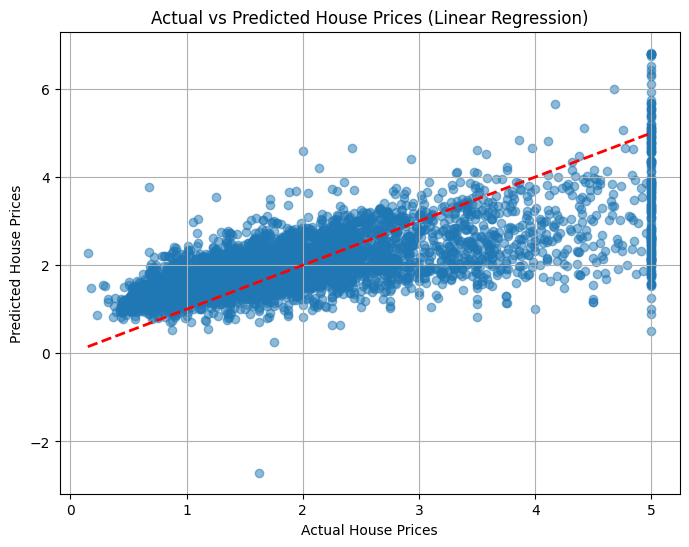

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target
print(housing_df)
df = housing_df


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Added mean_absolute_error import
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing()
X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y = pd.Series(california_housing.target)

X = X[['MedInc', 'AveRooms']]

print("Dataset loaded successfully.")
print(f"Features shape: {X.shape}, Target shape: {y.shape}")
print("\nData Set (X):")
print(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel training complete.")
print(f"Intercept (b0): {model.intercept_}")
print(f"Coefficients (b1, b2, ...): {model.coef_}")

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred) # Corrected assignment of MAE
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation on Test Data:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}") # Corrected f-string
print(f"R-squared Score (R2): {r2:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (Linear Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2) # Ideal line
plt.grid(True)
plt.show()

Model Evaluation on Test Data:

Mean Squared Error (MSE): 0.70

Mean Absolute Error (MAE): 0.62

R-squared Score (R2): 0.46

○ Decision Tree Regressor

Dataset shape (X_dt): (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Decision Tree Regressor trained successfully.

Mean Squared Error (MSE): 0.5674
Mean Absolute Error (MAE): 0.5573
R-squared Score (R²): 0.5677


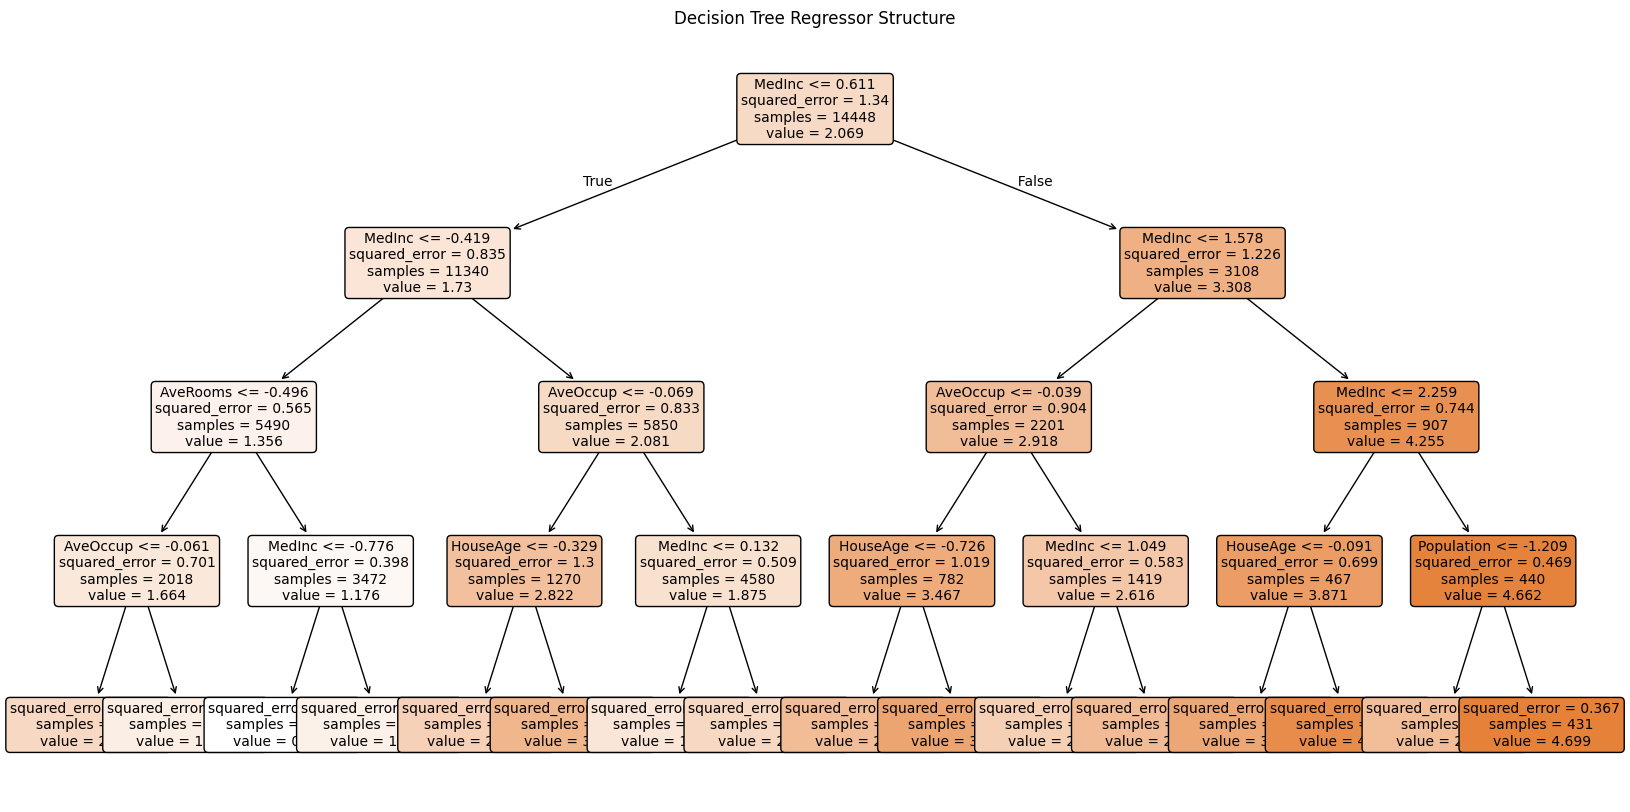

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# --- Start of Preprocessing Code (copied from cell w2sZFIIG66MF to define df_processed) ---
california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target

df = housing_df

if 'median_house_value' in df.columns:
    X = df.drop('median_house_value', axis=1)
    y = df['median_house_value']
else:
    print("Warning: 'median_house_value' column not found in housing_df. Please check your data.")
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

numerical_features = X.columns.tolist()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
    ],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X)

df_processed = pd.DataFrame(X_processed, columns=numerical_features)
# --- End of Preprocessing Code ---

X_dt = df_processed
y_dt = df['median_house_value']

print(f"Dataset shape (X_dt): {X_dt.shape}")
print(f"Features: {list(X_dt.columns)}\n")

X_train, X_test, y_train, y_test = train_test_split(X_dt, y_dt, test_size=0.3, random_state=42)

regressor = DecisionTreeRegressor(max_depth=4, random_state=42)

regressor.fit(X_train, y_train)

print("Decision Tree Regressor trained successfully.\n")

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

plt.figure(figsize=(20, 10))
plot_tree(regressor,
          feature_names=X_dt.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Regressor Structure")
plt.show()


Decision Tree Regressor

Mean Squared Error (MSE): 0.5674

Mean Absolute Error (MAE): 0.5573

R-squared Score (R²): 0.5677

○ Random Forest Regressor

Dataset shape (X_rf): (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Training set size: 16512 samples
Testing set size: 4128 samples

Random Forest Regressor trained successfully.

--- Model Evaluation ---
Mean Squared Error (MSE): 0.2555
Mean Absolute Error (MAE): 0.3276
R-squared (R2) Score: 0.8050
Sample Actual values: [0.48 0.46 5.   2.19 2.78]
Sample Predicted values: [0.51 0.74 4.92 2.53 2.27]


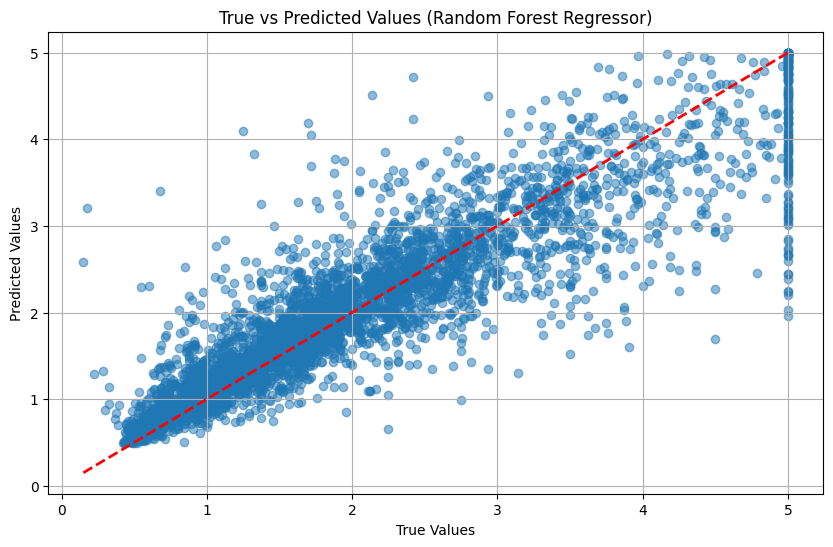

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# --- Start of Preprocessing Code to ensure df and df_processed are defined ---
california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target

df = housing_df

if 'median_house_value' in df.columns:
    X_full = df.drop('median_house_value', axis=1)
    y_full = df['median_house_value']
else:
    print("Warning: 'median_house_value' column not found in housing_df. Please check your data.")
    X_full = df.iloc[:, :-1]
    y_full = df.iloc[:, -1]

numerical_features = X_full.columns.tolist()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
    ],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X_full)

df_processed = pd.DataFrame(X_processed, columns=numerical_features)
# --- End of Preprocessing Code ---

X_rf = df_processed
y_rf = df['median_house_value']

print(f"Dataset shape (X_rf): {X_rf.shape}")
print(f"Features: {list(X_rf.columns)}\n")

X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

print("\nRandom Forest Regressor trained successfully.")

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}") # Fixed f-string here
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Sample Actual values: {y_test.values[:5].round(2)}")
print(f"Sample Predicted values: {y_pred[:5].round(2)}")

#map
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (Random Forest Regressor)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2) # Ideal line
plt.grid(True)
plt.show()

Random Forest Regressor

--- Model Evaluation ---

Mean Squared Error (MSE): 0.2555

Mean Absolute Error (MAE): 0.3276

R-squared (R2) Score: 0.8050

Sample Actual values: [0.48 0.46 5.   2.19 2.78]

Sample Predicted values: [0.51 0.74 4.92 2.53 2.27]

○ Gradient Boosting Regressor

Training set size: 16512 samples
Testing set size: 4128 samples

Gradient Boosting Regressor trained successfully.

--- Model Evaluation ---
Mean Squared Error (MSE): 0.2940
Mean Absolute Error (MAE): 0.3717
R-squared Score (R²): 0.7756


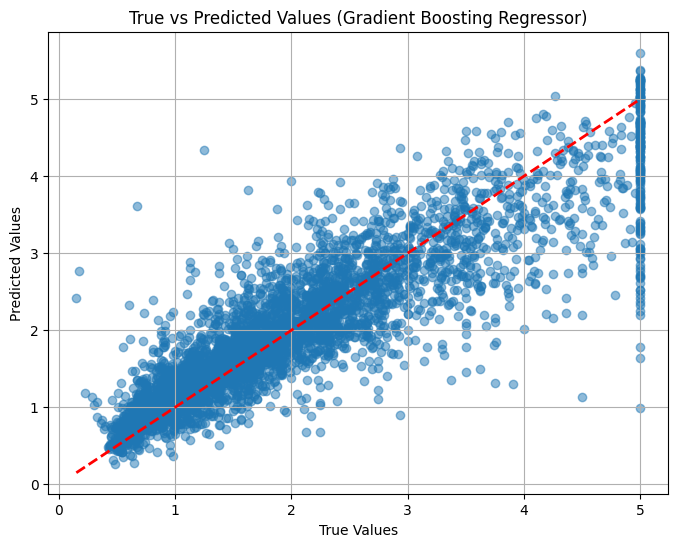

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Ensure mean_absolute_error is imported

# --- Start of Preprocessing Code to ensure df and df_processed are defined ---
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target

df = housing_df

if 'median_house_value' in df.columns:
    X_full = df.drop('median_house_value', axis=1)
    y_full = df['median_house_value']
else:
    print("Warning: 'median_house_value' column not found in housing_df. Please check your data.")
    X_full = df.iloc[:, :-1]
    y_full = df.iloc[:, -1]

numerical_features = X_full.columns.tolist()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
    ],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X_full)

df_processed = pd.DataFrame(X_processed, columns=numerical_features)
# --- End of Preprocessing Code ---

X_gbr = df_processed
y_gbr = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X_gbr, y_gbr, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


params = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'random_state': 42
}
gbr = GradientBoostingRegressor(**params)

gbr.fit(X_train, y_train)

print("\nGradient Boosting Regressor trained successfully.")

y_pred = gbr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

#map
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (Gradient Boosting Regressor)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2) # Ideal line
plt.grid(True)
plt.show()


Gradient Boosting Regressor

--- Model Evaluation ---

Mean Squared Error (MSE): 0.2940

Mean Absolute Error (MAE): 0.3717

R-squared Score (R²): 0.7756

○ Support Vector Regressor (SVR)

Dataset shape (X_svr): (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Training set size: 16512 samples
Testing set size: 4128 samples

Training SVR model... This may take a moment.
SVR model trained successfully.

--- Model Evaluation ---
Mean Squared Error (MSE): 0.3265
Mean Absolute Error (MAE): 0.3739
R-squared Score (R²): 0.7508


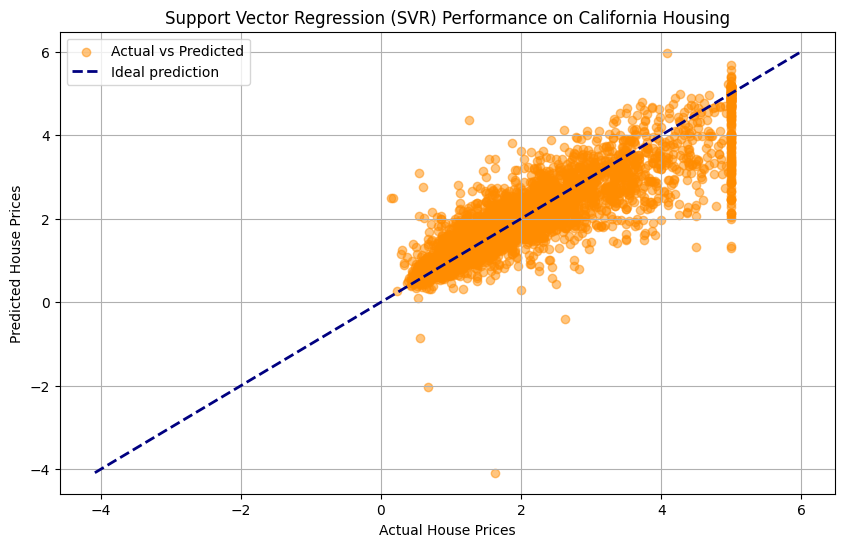

Sample actual values: [0.48 0.46 5.   2.19 2.78]
Sample predicted values: [0.49 1.39 4.7  2.43 2.89]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Correctly assign X_svr and y_svr from the California Housing dataset (df)
X_svr = df.drop('median_house_value', axis=1)
y_svr = df['median_house_value']

print(f"Dataset shape (X_svr): {X_svr.shape}")
print(f"Features: {list(X_svr.columns)}\n")

X_train, X_test, y_train, y_test = train_test_split(X_svr, y_svr, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
y_train_scaled = sc_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

X_test_scaled = sc_X.transform(X_test)

svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)

print("\nTraining SVR model... This may take a moment.")
svr_rbf.fit(X_train_scaled, y_train_scaled)
print("SVR model trained successfully.")

y_pred_scaled = svr_rbf.predict(X_test_scaled)

y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score (R²): {r2:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='darkorange', label='Actual vs Predicted', alpha=0.5)
plt.plot([min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
         [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())],
         color='navy', lw=2, linestyle='--', label='Ideal prediction')
plt.xlabel('Actual House Prices')
plt.ylabel('Predicted House Prices')
plt.title('Support Vector Regression (SVR) Performance on California Housing')
plt.legend()
plt.grid(True)
plt.show()

print(f"Sample actual values: {y_test.values[:5].round(2)}")
print(f"Sample predicted values: {y_pred[:5].round(2)}")

Support Vector Regressor (SVR)

--- Model Evaluation ---

Mean Squared Error (MSE): 0.3265

Mean Absolute Error (MAE): 0.3739

R-squared Score (R²): 0.7508

Sample actual values: [0.48 0.46 5.   2.19 2.78]

Sample predicted values: [0.49 1.39 4.7  2.43 2.89]

● For each algorithm: Provide a brief explanation of how it works. Explain why it
might be suitable for this dataset.

Linear regression

Linear regression is a supervised machine learning algorithm that models the relationship between a dependent variable (the target outcome) and one or more independent variables (predictors or features) by fitting a linear equation to observed data

The Equation: It follows the basic formula of a straight line, \(y=mx+b\) (or \(y=\beta _{0}+\beta _{1}x\) in statistical terms), where \(\beta _{0}\) is the y-intercept and \(\beta _{1}\) is the slope

Finding the "Best Fit": The algorithm aims to find the line that minimizes the total error between actual data points and predicted values

Ordinary Least Squares (OLS): The most common method used is "Least Squares," which calculates the line by minimizing the sum of the squared differences (residuals) between observed and predicted values

Optimization: In machine learning, techniques like Gradient Descent are often used to iteratively update the model's weights to reach the lowest possible error

Linear regression is highly effective when specific data conditions are met. It is likely suitable for your dataset if it aligns with these criteria:

Continuous Target Variable: It is designed to predict numerical, continuous values (e.g., house prices, temperature, or sales) rather than categories

Linear Relationship: There is a clear linear trend between your features and the target. This can be verified using a scatter plot.

Interpretability: If your goal is not just prediction but also understanding how much each feature influences the outcome, linear regression provides easy-to-interpret coefficients


Decision Tree Regressor

A Decision Tree Regressor is a supervised machine learning algorithm that predicts continuous numerical outcomes by recursively partitioning data into smaller, more homogeneous groups based on input features

Recursive Binary Splitting: Starting at the "root" (the entire dataset), the algorithm evaluates all possible splits across every feature to find the one that best reduces prediction error. In regression, the most common metric for this is Mean Squared Error (MSE) or variance reduction

Tree Structure: The dataset is split into two child nodes. This process is repeated recursively, creating branches and internal decision nodes until a stopping condition is met (e.g., maximum depth or a minimum number of samples per node)

Leaf Node Predictions: The terminal nodes, or "leaves," represent the final output. For a new data point, the model follows the decision rules from the root to a leaf; the prediction is typically the average (mean) of the target values of the training samples in that leaf.

Non-Linear Relationships: Unlike linear regression, decision trees excel at capturing complex, non-linear dependencies between variables without needing to transform them first.

Mixed Data Types: They can handle both numerical and categorical features simultaneously, simplifying the data preparation process

Low Preprocessing Requirements: The model is insensitive to the scale of features, meaning it does not require normalization or standardization

Robustness to Outliers: Because predictions are based on localized regions of data (splits), individual extreme values (outliers) do not distort the entire model as they might in linear regression.

High Interpretability: The final model is a "white box" that can be easily visualized and explained to stakeholders as a series of simple "if-then" rules

Random Forest Regressor

A Random Forest Regressor is an ensemble machine learning algorithm that combines multiple decision trees to produce a single, more accurate numerical prediction. It is widely used for predicting continuous values like house prices or stock trends

The algorithm operates through a process called Bootstrap Aggregating (Bagging) and feature randomness

Bootstrapping: It creates numerous individual decision trees, each trained on a different random subset of the training data (sampled with replacement)

Feature Randomness: When splitting nodes within a tree, the algorithm considers only a random subset of features rather than all available ones. This ensures the trees are uncorrelated and capture diverse patterns

Aggregation: Each tree makes its own prediction. For regression, the final output is the average of all individual tree predictions.

Random Forest is highly effective for modern, real-world datasets due to several key strengths:

Reduces Overfitting: While a single decision tree often "memorizes" training data (high variance), averaging multiple trees cancels out individual errors, leading to better generalization on new data

Handles Non-Linearity: It can capture complex, non-linear relationships between variables without requiring the data to follow a specific distribution (unlike linear regression).

Robustness to Messy Data: It handles missing values effectively and is less sensitive to outliers because they typically only affect a few trees in the forest

Feature Importance: It provides a built-in mechanism to rank which features have the most influence on the prediction, helping researchers understand the underlying data

Scalability: It works well with high-dimensional data (datasets with many columns) and can be parallelized to speed up training.

Gradient Boosting Regressor

A Gradient Boosting Regressor is an ensemble machine learning algorithm that builds a strong predictive model by combining multiple "weak" models, typically simple decision trees, in a sequential manner.

Initialization: The process begins with a simple initial prediction, usually the mean of the target values in the training set

Iterative Correction: The algorithm builds trees one after another. Instead of predicting the final target directly, each new tree is trained to predict the residuals (the errors or differences between the actual values and the current ensemble's predictions)

Gradient Optimization: It uses a gradient descent approach to minimize a loss function (like Mean Squared Error). Each new tree takes a "step" in the direction that reduces the overall error most effectively.

Additive Updates: The new tree's predictions are multiplied by a learning rate (shrinkage) and added to the previous model's total. This small, controlled step prevents the model from overfitting to specific data points too quickly

Final Prediction: The final output is the sum of the initial prediction and the scaled contributions of every tree in the sequence

Captures Complex Relationships: It excels at identifying non-linear patterns and complex interactions between variables that simple linear models might miss

High Predictive Accuracy: Because it iteratively focuses on and fixes specific errors, it often delivers state-of-the-art results for structured, tabular data

Robustness to Diverse Data: It can handle mixed data types (numerical and categorical) and is relatively robust to outliers and missing values without extensive preprocessing

Flexibility: You can adapt the algorithm to your specific needs by choosing different loss functions (e.g., Mean Absolute Error for better handling of outliers).

Feature Importance: It provides clear insights into which features in your dataset are most influential in making predictions.

Support Vector Regressor (SVR)  

Support Vector Regression (SVR) is a supervised learning algorithm that predicts continuous numerical values. While related to Support Vector Machines (SVM) used for classification, SVR adapts this logic to find a function that best fits a dataset while maintaining a specific margin of tolerance.

SVR aims to find a hyperplane (a best-fit line or surface) that contains the maximum number of data points within a defined boundary. Its operation is defined by three core components:

Epsilon Margin (\(\varepsilon \)): A predefined threshold or "tube" around the hyperplane. Errors within this tube are ignored, meaning no penalty is given for data points that fall inside this margin

Support Vectors: These are the critical data points that lie on or outside the epsilon boundary. Unlike linear regression, which minimizes error for every point, SVR focuses solely on these "support vectors" to define the shape and position of the hyperplane

Kernel Trick: SVR can handle complex, non-linear data by using kernels (e.g., Linear, Polynomial, or Radial Basis Function) to map the original data into a higher-dimensional space where a linear hyperplane can be easily identified.

SVR is often preferred over traditional methods like linear regression in 2026 for datasets with the following characteristics:

Robustness to Outliers: Because SVR primarily considers data points near the decision boundary (support vectors) and ignores points within the epsilon margin, it is significantly less sensitive to outliers that deviate from the main trend

Captures Non-Linear Relationships: Through the use of non-linear kernels, SVR can capture intricate, "wavy," or complex patterns that simple linear models often miss

Effective for High-Dimensional Data: It performs well in scenarios with many features (high-dimensional spaces) and provides strong generalization, meaning it often makes more accurate predictions on new, unseen data.

Small to Medium Datasets: SVR is particularly effective when training data is limited, as it depends only on a subset of the data (support vectors) to build its decision boundary.

3. Model Evaluation and Comparison (2 marks):  
● Evaluate the performance of each algorithm using the following metrics:  
○ Mean Squared Error (MSE)  
○ Mean Absolute Error (MAE)  
○ R-squared Score (R²)  
● Compare the results of all models and identify: The best-performing algorithm
with justification and the worst-performing algorithm with reasoning.  

○ Mean Squared Error (MSE)


In statistical modeling and machine learning, a lower Mean Squared Error (MSE) is better

○ Linear Regression - 0.70

○ Decision Tree Regressor -0.5674

○ Random Forest Regressor - 0.2555

○ Gradient Boosting Regressor- 0.2940

○ Support Vector Regressor (SVR) - 0.3265

Lowest is 0.2555  --  Random Forest Regressor is better

○ Mean Absolute Error (MAE)

For Mean Absolute Error (MAE), lower values are better

○ Linear Regression - 0.62

○ Decision Tree Regressor - 0.5573

○ Random Forest Regressor - 0.3276

○ Gradient Boosting Regressor - 0.3717

○ Support Vector Regressor (SVR) - 0.3739

Lowest is 0.3276 - Random Forest Regressor is better

 R-squared Score (R²)

In general, a higher R-squared (\(R^{2}\)) score is better because it indicates that the model explains a larger proportion of the variance in the data. However, a "good" score depends heavily on the field of study and the specific goals of the model.

○ Linear Regression - 0.46

○ Decision Tree Regressor - 0.5677

○ Random Forest Regressor - 0.8050

○ Gradient Boosting Regressor - 0.7756

○ Support Vector Regressor (SVR) - 0.7508

Highest value is 0.8050 - Random Forest Regressor is better

4. Timely Submission (1 mark):  
● Submit your code in a Jupyter Notebook format via a GitHub link.  
● Ensure that your code is well-documented and explanations are clear and
concise.  
● Submission Guidelines: Use Python and Jupyter Notebook for implementation.
Submit the GitHub repository link containing the code and all necessary files.
Ensure proper documentation, including code comments and markdown
explanations.  
Total Score: 10

ROUGH NOTES

Linear Regressor

Model Evaluation on Test Data:

Mean Squared Error (MSE): 0.70

Mean Absolute Error (MAE): 0.62

R-squared Score (R2): *0.46*

Decision Tree Regressor

Mean Squared Error (MSE): 0.5674

Mean Absolute Error (MAE): 0.5573

R-squared Score (R²): 0.5677


Random Forest Regressor

--- Model Evaluation ---

Mean Squared Error (MSE): 0.2555

Mean Absolute Error (MAE): 0.3276

R-squared (R2) Score: 0.8050

Sample Actual values: [0.48 0.46 5.   2.19 2.78]

Sample Predicted values: [0.51 0.74 4.92 2.53 2.27]

Gradient Boosting Regressor

--- Model Evaluation ---

Mean Squared Error (MSE): 0.2940

Mean Absolute Error (MAE): 0.3717

R-squared Score (R²): 0.7756


Support Vector Regressor (SVR)

--- Model Evaluation ---

Mean Squared Error (MSE): 0.3265

Mean Absolute Error (MAE): 0.3739

R-squared Score (R²): 0.7508
Sample actual values: [0.48 0.46 5.   2.19 2.78]

Sample predicted values: [0.49 1.39 4.7  2.43 2.89]

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
california_housing = fetch_california_housing(as_frame=True)
housing_df = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
housing_df['median_house_value'] = california_housing.target
print(housing_df)
df = housing_df

if 'median_house_value' in df.columns:
    X = df.drop('median_house_value', axis=1)
    y = df['median_house_value']
else:
    print("Warning: 'median_house_value' column not found in housing_df. Please check your data.")
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
print("California Housing dataset successfully configured from existing 'housing_df'.")
print(df)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  median_house_value  
